In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, num_classes)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

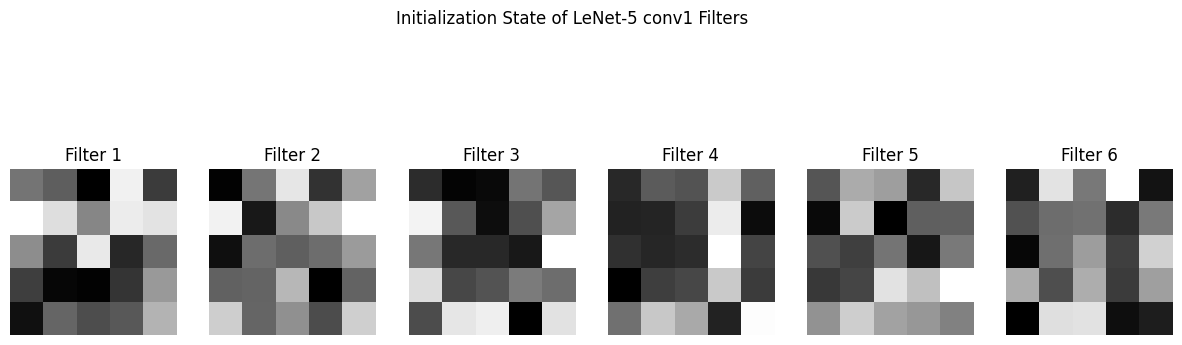

In [2]:
import matplotlib.pyplot as plt

model = LeNet5(num_classes=10)

filters = model.conv1.weight.detach()

fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(filters[i][0], cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')

plt.suptitle('Initialization State of LeNet-5 conv1 Filters')
plt.show()

100.0%
100.0%
100.0%
100.0%


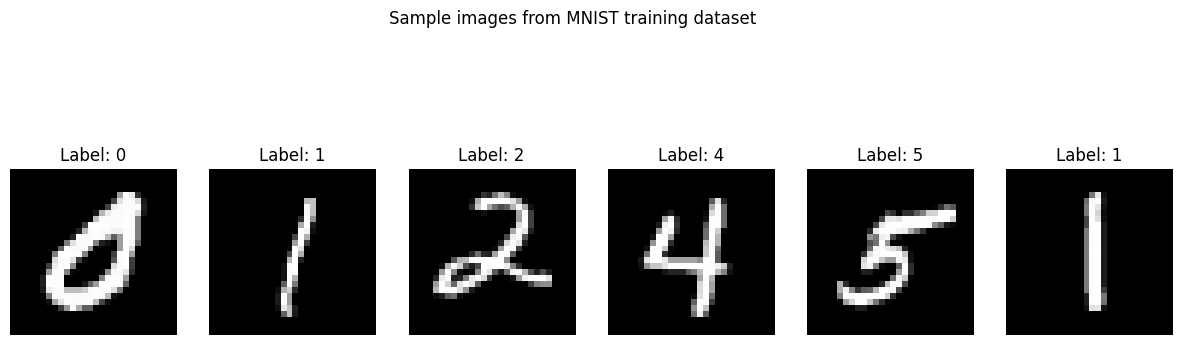

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')

plt.suptitle('Sample images from MNIST training dataset')
plt.show()

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

learning_rate = 0.001
batch_size = 64
num_epochs = 5

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Training on {device}")
model.train()

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}")

print("Training complete")

Training on cpu
Epoch [1/5], Step [100/938], Loss: 1.2285
Epoch [1/5], Step [200/938], Loss: 1.5673
Epoch [1/5], Step [300/938], Loss: 1.7976
Epoch [1/5], Step [400/938], Loss: 1.9845
Epoch [1/5], Step [500/938], Loss: 2.1428
Epoch [1/5], Step [600/938], Loss: 2.2689
Epoch [1/5], Step [700/938], Loss: 2.4123
Epoch [1/5], Step [800/938], Loss: 2.5272
Epoch [1/5], Step [900/938], Loss: 2.6303
Epoch [2/5], Step [100/938], Loss: 0.0919
Epoch [2/5], Step [200/938], Loss: 0.1752
Epoch [2/5], Step [300/938], Loss: 0.2488
Epoch [2/5], Step [400/938], Loss: 0.3236
Epoch [2/5], Step [500/938], Loss: 0.4048
Epoch [2/5], Step [600/938], Loss: 0.4814
Epoch [2/5], Step [700/938], Loss: 0.5559
Epoch [2/5], Step [800/938], Loss: 0.6246
Epoch [2/5], Step [900/938], Loss: 0.6938
Epoch [3/5], Step [100/938], Loss: 0.0586
Epoch [3/5], Step [200/938], Loss: 0.1172
Epoch [3/5], Step [300/938], Loss: 0.1733
Epoch [3/5], Step [400/938], Loss: 0.2247
Epoch [3/5], Step [500/938], Loss: 0.2773
Epoch [3/5], Step 

In [5]:
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy of the model on the 10000 test images: {accuracy:.2f}%")

Accuracy of the model on the 10000 test images: 98.85%
